## EDA of occurrence table

This notebook was used to create fig 2.
The composite of the figure is created by notebook `compose_map_province`.

In [16]:
import pandas as pd
import os

df_occ = pd.read_csv('../dados_raw/checklist_occurrences_12Jun2026.csv', low_memory=False)
df_prov_codes = pd.read_csv('../dados_raw/province_ids.csv')


# df_occ_valid_taxa = df_occ[(df_occ['taxonomicStatus'].str.lower() == 'accepted') | (df_occ['taxonomicStatus'].str.lower() == 'synonym')].reset_index(drop=True)

df_occ_valid_taxa = df_occ.copy()

df_occ_valid_taxa.shape

(43718, 73)

In [17]:
df_prov_codes

,provincia_process,PROVID,prov_code
0,Estremadura,7,ES
1,Minho,1,MI
2,Algarve,11,AL
3,Beira Alta,4,BA
4,Baixo Alentejo,10,BAl
5,Alto Alentejo,9,AA
6,Trás-os-Montes e Alto Douro,2,TM
7,Beira Litoral,5,BL
8,Douro Litoral,3,DL
9,Ribatejo,8,RI


In [18]:
# merge df_occ with df_prov_codes to get province codes
df_occ_valid_taxa = df_occ_valid_taxa.merge(df_prov_codes, left_on='provincia_process', right_on='provincia_process', how='left')

Verificar se há espécies aceites com mais do que um ID

In [19]:
# Group by acceptedNameUsageID and count unique acceptedNameUsage values
unique_counts = df_occ_valid_taxa.groupby('acceptedNameUsageID')['acceptedNameUsage'].nunique()

# Filter for IDs with more than one unique acceptedNameUsage
inconsistent_ids = unique_counts[unique_counts > 1].index.tolist()

# Display the list of inconsistent acceptedNameUsageID
print("acceptedNameUsageID with more than one acceptedNameUsage:")
print(inconsistent_ids)

acceptedNameUsageID with more than one acceptedNameUsage:
[]


In [20]:
df_sem_beira = df_occ_valid_taxa[(df_occ_valid_taxa['provincia_process'] != 'Beira')].reset_index(drop=True)

In [21]:
# count number of rows with value in column 'provincia_process', and percent of total rows in df_sem_beira
num_rows_with_provincia_process = df_sem_beira['provincia_process'].notna().sum()
total_rows = len(df_sem_beira)
percent_with_provincia_process = (num_rows_with_provincia_process / total_rows) * 100
print(f"Number of rows with value in 'provincia_process': {num_rows_with_provincia_process}")
print(f"Percentage of rows with value in 'provincia_process': {percent_with_provincia_process:.2f}%")

Number of rows with value in 'provincia_process': 42705
Percentage of rows with value in 'provincia_process': 97.83%


In [22]:
# number and percentage of rows with value in column decimalLatitude
num_rows_with_decimalLatitude = df_sem_beira['decimalLatitude'].notna().sum()
percent_with_decimalLatitude = (num_rows_with_decimalLatitude / total_rows) * 100
print(f"Number of rows with value in 'decimalLatitude': {num_rows_with_decimalLatitude}")
print(f"Percentage of rows with value in 'decimalLatitude': {percent_with_decimalLatitude:.2f}%")

Number of rows with value in 'decimalLatitude': 32492
Percentage of rows with value in 'decimalLatitude': 74.44%


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

outdir = '../images/hist_provinces'
os.makedirs(outdir, exist_ok=True)

df = df_sem_beira.copy()

# ---------- prepare year and decade ----------
df["year_ref"] = pd.to_numeric(
    df["year_ref"], errors="coerce"
)
df = df.dropna(subset=["year_ref"])
df["year_ref"] = df["year_ref"].astype(int)

df["decade"] = (df["year_ref"] // 10) * 10

# fixed decade range starting at 1800
max_decade = df["decade"].max()
all_decades = np.arange(1800, max_decade + 10, 10)




### Create plots with number of occurrences per decade and accummulated number of species 

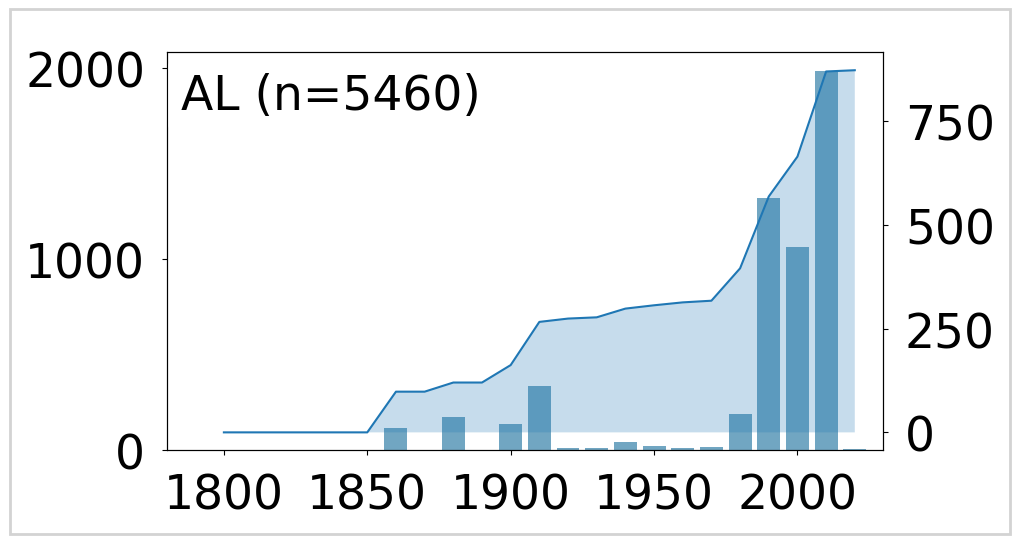

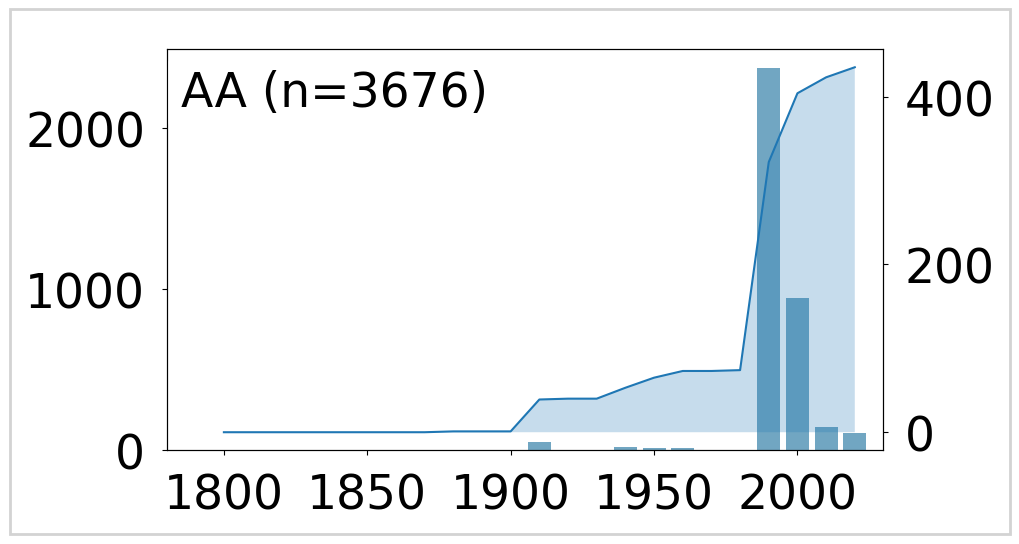

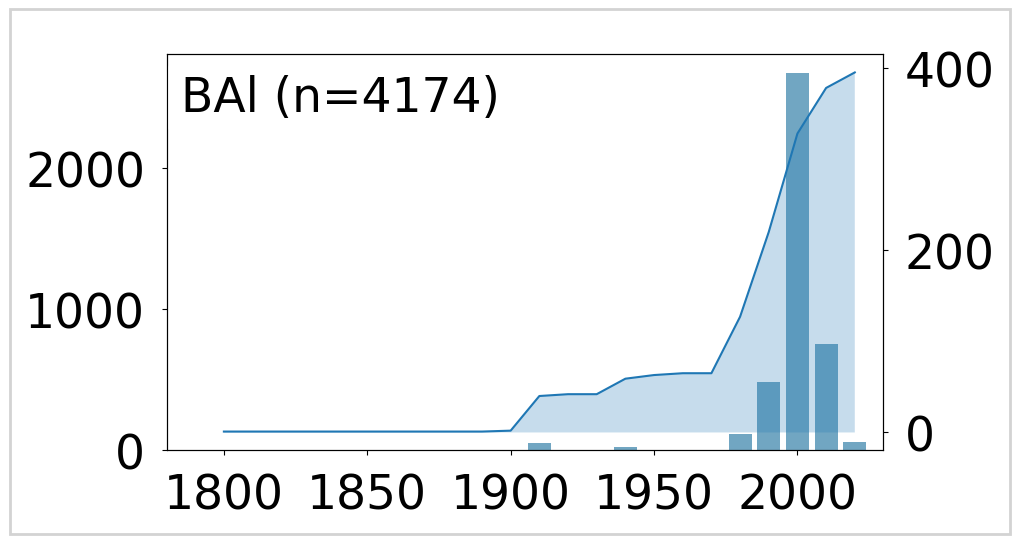

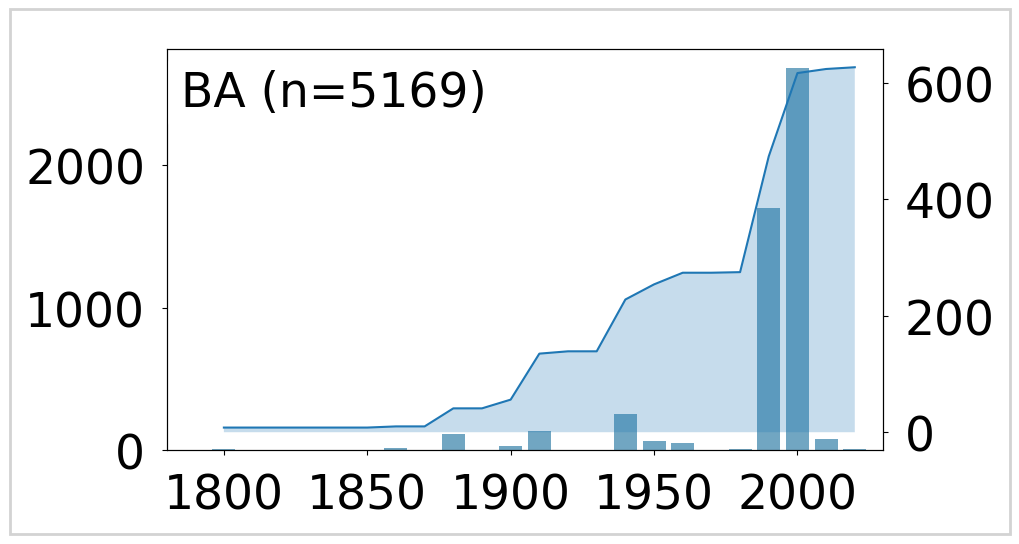

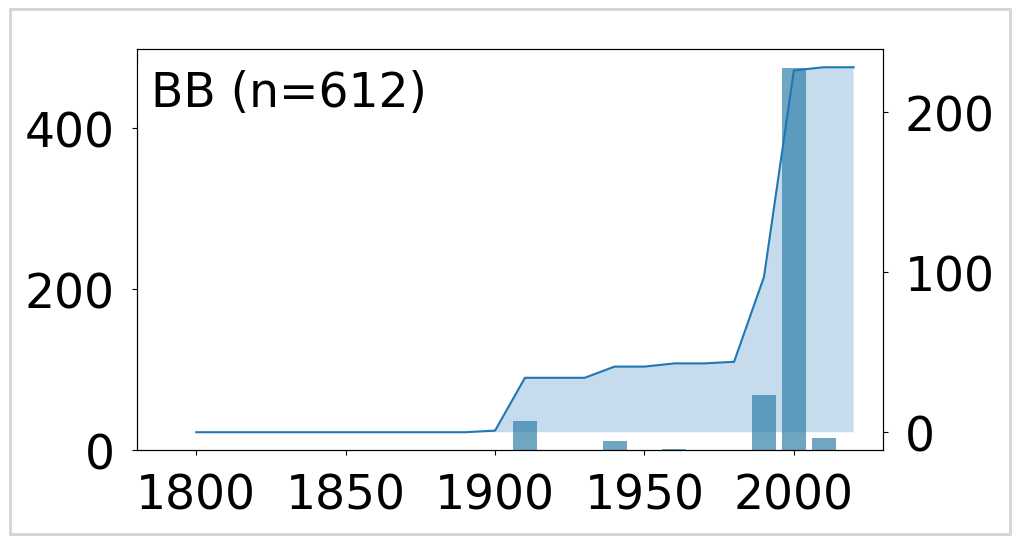

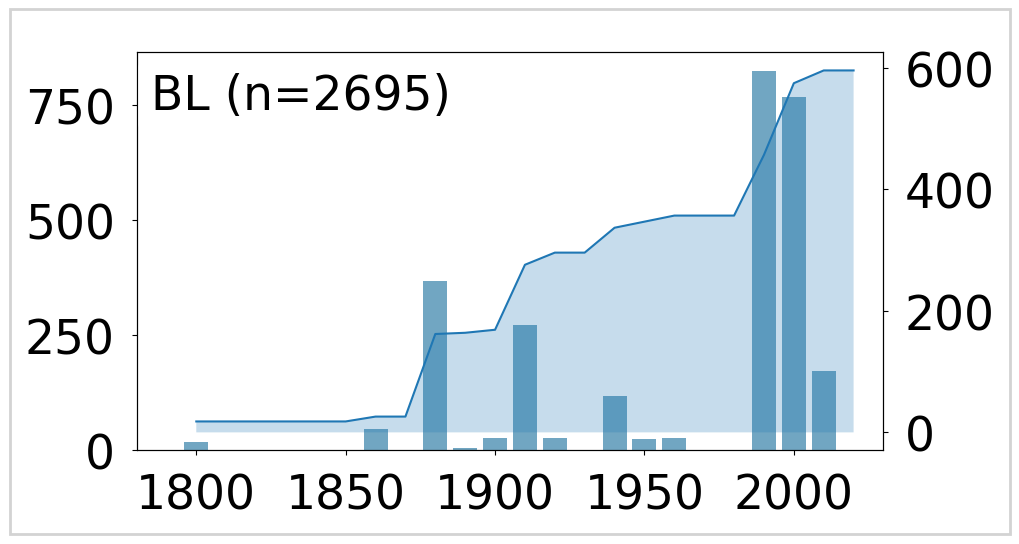

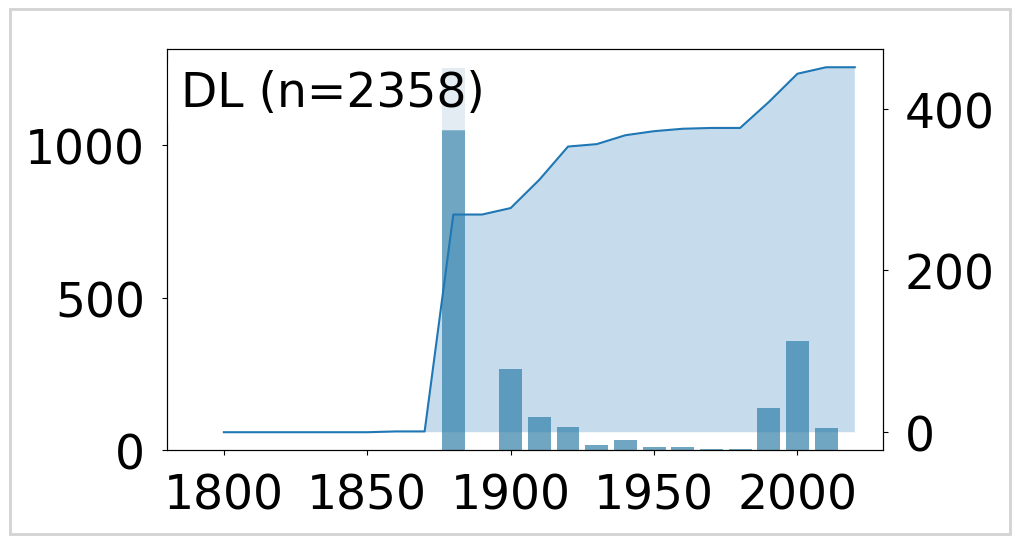

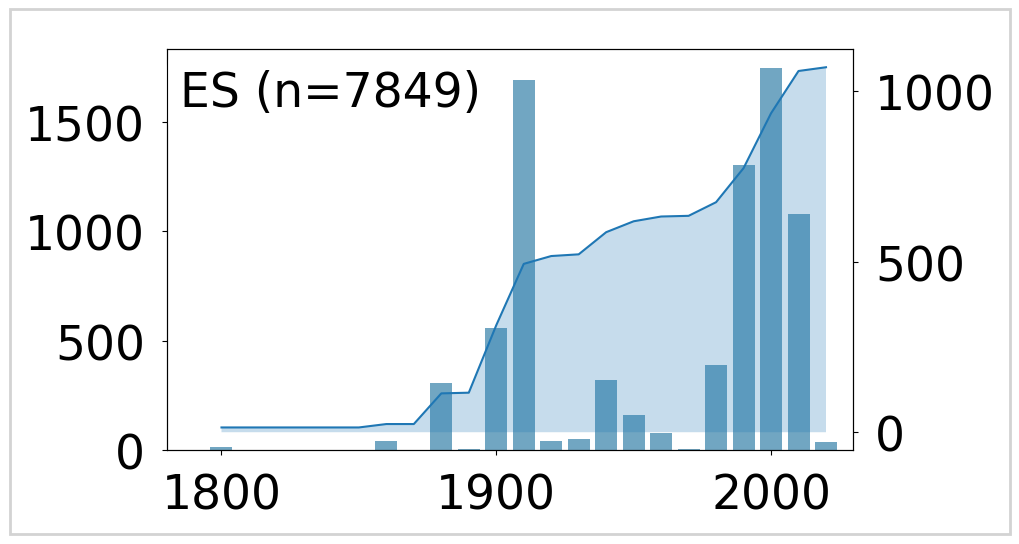

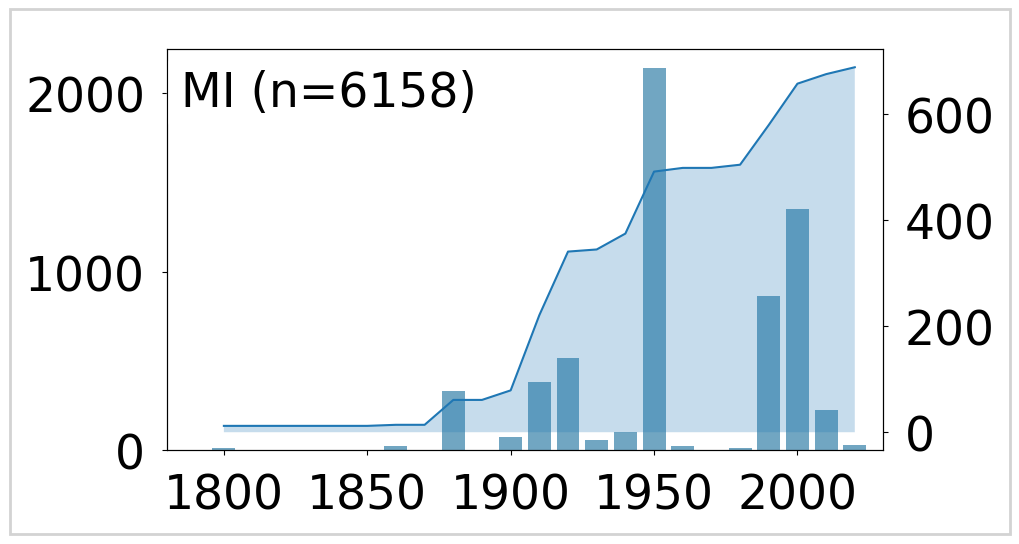

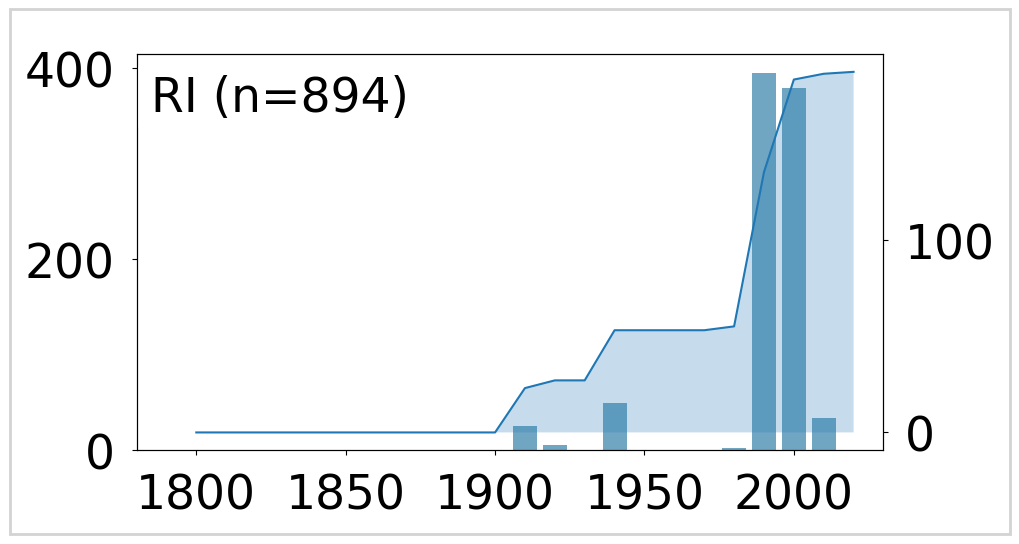

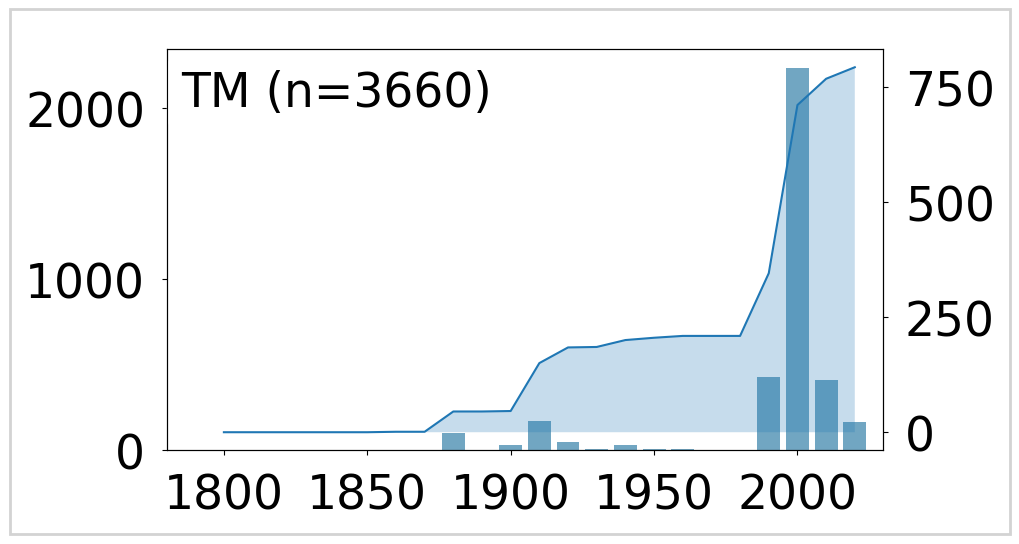

In [24]:


# ---------- plotting function ----------
def plot_province_history(province_name, df, all_decades):
    fontsize = 34

    sub = df[df["provincia_process"] == province_name].copy()

    prov_code = sub["prov_code"].iloc[0] if not sub["prov_code"].isna().all() else "unknown"

    # occurrences per decade
    occ_decade = (
        sub.groupby("decade")
        .size()
        .reindex(all_decades, fill_value=0)
        .reset_index()
    )
    occ_decade.columns = ["decade", "n_occurrences"]

    # cumulative taxa by first decade
    taxa_first_year = (
        sub.groupby("acceptedNameUsageID")["year_ref"]
        .min()
        .reset_index()
    )
    taxa_first_year["decade"] = (
        taxa_first_year["year_ref"] // 10
    ) * 10

    taxa_decade = (
        taxa_first_year.groupby("decade")
        .size()
        .reindex(all_decades, fill_value=0)
        .cumsum()
        .reset_index()
    )
    taxa_decade.columns = ["decade", "cumulative_taxa"]

    # ---------- plot ----------
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # bars
    ax1.bar(occ_decade["decade"], occ_decade["n_occurrences"], width=8, color='#3581a8', alpha=0.7)
    # ax1.set_ylabel("Occurrences", fontsize=28)
    # ax1.set_xlabel("Decade", fontsize=28)
    # ax1.set_title(f"{province_name} (n={len(sub)})", fontsize=32)
    ax1.set_xlim(1780, max_decade + 10)
    ax1.tick_params(axis='x', labelsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)

    # cumulative shaded area
    ax2 = ax1.twinx()
    ax2.fill_between(
        taxa_decade["decade"],
        taxa_decade["cumulative_taxa"],
        alpha=0.25
    )
    ax2.plot(
        taxa_decade["decade"],
        taxa_decade["cumulative_taxa"]
    )
    ax2.tick_params(axis='y', labelsize=fontsize)

    # ax2.set_ylabel("Cumulative taxa", fontsize=28)
    
    # 1️⃣  FIX THE MARGINS – this keeps the plot rectangle the same,
    #     regardless of how wide the tick labels become.
    # fig.subplots_adjust(left=0.15, right=0.85, bottom=0.15, top=0.90)

    # ------------------------------------------------------------------
    # 2️⃣  OPTIONAL: Add a little padding so the tick labels never touch the edge
    # ------------------------------------------------------------------
    # The `pad` argument (in points) is applied in addition to the
    # manual margins above.  4‑8 points is usually enough.
    ax1.tick_params(pad=12)
    ax2.tick_params(pad=12)


    # ---------- BACKGROUND ----------
    # ax1.set_facecolor('#C8C8C8')   # light gray for the main axis
    # ax2.set_facecolor('#C8C8C8')   # same for the twin axis
    # fig.patch.set_facecolor("#C8C8C8")   # optional: light gray for the whole figure

    # 2️⃣  (Optional) Add a frame around the whole figure
    import matplotlib.patches as mpatches

    frame_rect = mpatches.Rectangle(
        (0, 0),
        1,
        1.05,
        transform=fig.transFigure,
        linewidth=2,
        edgecolor="lightgray",
        facecolor="none",
        zorder=10
    )
    fig.add_artist(frame_rect)

    # -------------------------------------------------------------
    # 3️⃣  *** NEW: put a text box in the top‑left corner ***
    # -------------------------------------------------------------
    # Use the axes‑fraction coordinate system (0,0 = bottom‑left,
    # 1,1 = top‑right).  A small offset keeps the text away from the
    # border, and the `bbox` gives a light background so it stays legible
    # even on dark bars.
    ax1.text(
        0.02,              # 2 % from the left
        0.95,              # 95 % from the bottom (i.e. top)
        f"{prov_code} (n={len(sub)})",
        transform=ax1.transAxes,  # interpret coordinates in axes space
        fontsize=fontsize,
        verticalalignment="top",   # anchor the top of the text
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
        ),
    )


    plt.tight_layout()
    
    
    # save the plot
    safe_province = re.sub(r'[^\w\-_\.]', '_', province_name)
    fname = os.path.join(outdir, f"{safe_province}_nolabel.png")
    plt.savefig(fname, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# ---------- all provinces ----------
for province in sorted(df["provincia_process"].dropna().unique()):
    plot_province_history(province, df, all_decades)

## create plot for the whole country

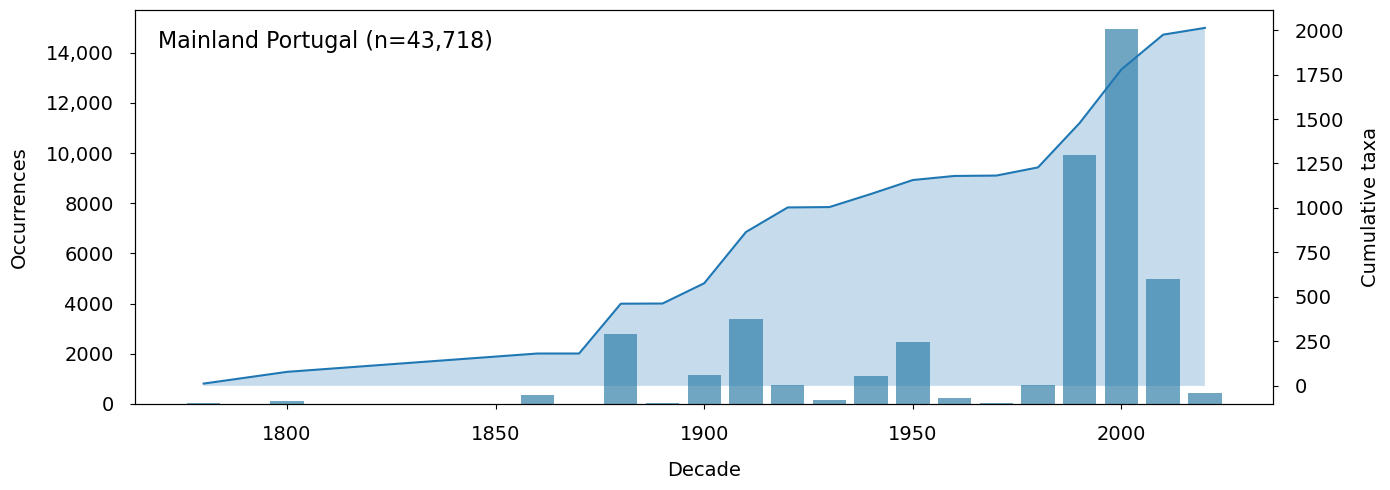

In [31]:
from matplotlib.ticker import FuncFormatter

def thousands_if_5digits(x, pos):
    x = int(round(x))
    if abs(x) >= 10000:
        return f"{x:,}"
    return f"{x}"

df = df_occ_valid_taxa.copy()

fontsize = 14

# ---------- prepare decade ----------
df["year_ref"] = pd.to_numeric(
  df["year_ref"], errors="coerce"
)

df = df.dropna(subset=["year_ref"])
df["year_ref"] = df["year_ref"].astype(int)

df["decade"] = (df["year_ref"] // 10) * 10

# ---------- occurrences per decade ----------
occ_decade = (
  df.groupby("decade")
  .size()
  .reset_index(name="n_occurrences")
  .sort_values("decade")
)

# ---------- cumulative taxa over time ----------
taxa_first_year = (
  df.groupby("acceptedNameUsageID")["year_ref"]
  .min()
  .reset_index()
)
taxa_first_year["decade"] = (
  taxa_first_year["year_ref"] // 10
) * 10

taxa_decade = (
  taxa_first_year.groupby("decade")
  .size()
  .cumsum()
  .reset_index(name="cumulative_taxa")
)

# ---------- merge decades ----------
decades = sorted(set(occ_decade["decade"]) | set(taxa_decade["decade"]))
full = pd.DataFrame({"decade": decades})

full = full.merge(occ_decade, on="decade", how="left")
full = full.merge(taxa_decade, on="decade", how="left")

full["n_occurrences"] = full["n_occurrences"].fillna(0)
full["cumulative_taxa"] = full["cumulative_taxa"].ffill().fillna(0)

# ---------- plot ----------
fig, ax1 = plt.subplots(figsize=(14, 5))

# bars
ax1.bar(full["decade"], full["n_occurrences"], width=8, color='#3581a8', alpha=0.7)
ax1.set_ylabel("Occurrences", fontsize=fontsize, labelpad=12)
ax1.set_xlabel("Decade",  fontsize=fontsize,labelpad=12)
# ax1.set_title(f"Mainland Portugal (n={len(df)})", fontsize=fontsize)
ax1.tick_params(axis='x', labelsize=fontsize)
ax1.tick_params(axis='y', labelsize=fontsize)

# cumulative shaded area
ax2 = ax1.twinx()
ax2.fill_between(
  full["decade"],
  full["cumulative_taxa"],
  alpha=0.25
)
ax2.plot(full["decade"], full["cumulative_taxa"])
ax2.set_ylabel("Cumulative taxa", fontsize=fontsize,labelpad=12)
ax2.tick_params(axis='y', labelsize=fontsize)

# Format y-axis numbers with thousands separators
ax1.yaxis.set_major_formatter(FuncFormatter(thousands_if_5digits))
ax2.yaxis.set_major_formatter(FuncFormatter(thousands_if_5digits))

ax1.tick_params(pad=12)
ax2.tick_params(pad=12)

    # -------------------------------------------------------------
    # 3️⃣  *** NEW: put a text box in the top‑left corner ***
    # -------------------------------------------------------------
    # Use the axes‑fraction coordinate system (0,0 = bottom‑left,
    # 1,1 = top‑right).  A small offset keeps the text away from the
    # border, and the `bbox` gives a light background so it stays legible
    # even on dark bars.
n = len(df)
n_text = f"{n:,}" if n >= 10000 else str(n)

ax1.text(
    0.02,              # 2 % from the left
    0.95,              # 95 % from the bottom (i.e. top)
    f"Mainland Portugal (n={len(df):,})",
    transform=ax1.transAxes,  # interpret coordinates in axes space
    fontsize=16,
    verticalalignment="top",   # anchor the top of the text
    color="black",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
   ),
)




plt.tight_layout()


# save the plot
fname = os.path.join(outdir, "whole_dataset.png")
plt.savefig(fname, dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

Prepare table with counts of 

In [26]:
df_sem_beira

,id_serial_number,is_train,ID,ID 1,id_coutinho,ID 2,occurrenceID,basisOfRecord,scientificName,acceptedNameUsage,...,substrate_merge,substrato_RAG,substrato,herbario,tituloartigo,id_referencia_biblio,associatedReferences,year_ref,PROVID,prov_code
0,44798,NaN,NaN,NaN,NaN,NaN,73518a1d-e7f0-4e68-b252-e018f2954896,materialCitation,Physcia erumpens Moberg,Physcia erumpens Moberg,...,NaN,corticolous,NaN,NaN,Studies on Physcia III. Three Physcia-species ...,T6BJ2QEY,"Moberg, R. (1989). Studies on Physcia - III Th...",1989,7.0,ES
1,44799,NaN,NaN,NaN,NaN,NaN,cf6e74af-c7a5-4a49-a5d4-9c7fd7c388c0,materialCitation,Physcia undulata Moberg,Physcia undulata Moberg,...,NaN,corticolous,NaN,NaN,Studies on Physcia III. Three Physcia-species ...,T6BJ2QEY,"Moberg, R. (1989). Studies on Physcia - III Th...",1989,7.0,ES
2,1,NaN,2653G,2653G,NaN,NaN,b1fd7de3-3c07-4517-bc00-ef8139bba4a1,materialCitation,Abrothallus bertianus De Not.,Abrothallus bertianus De Not.,...,"Liquenícola, on Parmelia, ad rupes graniticas,...","lichenicolous, Liquenícola, on Parmelia, ad ru...",NaN,"LISU, Lichenes Lusitaniae selecti exsiccati Nº...",Lichenicolous fungi from the Iberian Peninsula...,JVW8RPGB,"Martínez, I. (2002). Lichenicolous fungi from ...",2002,7.0,ES
3,2,NaN,0001J,0001J,NaN,NaN,869a2422-59d8-4db4-bd52-6b4e60ff3fc5,materialCitation,Abrothallus bertianus De Not.,Abrothallus bertianus De Not.,...,on Xanthoparmelia on Cupressus,"lichenicolous, on Xanthoparmelia on Cupressus",NaN,NaN,Lichens and lichenicolous fungi of Estremadura...,5J6348NR,"van den Boom, P. P. G. (2017). Lichens and lic...",2017,7.0,ES
4,3,NaN,000001P,000001P,NaN,NaN,09a98e92-d552-47e3-9fc7-1a68b4300614,materialCitation,Abrothallus bertianus De Not.,Abrothallus bertianus De Not.,...,NaN,NaN,NaN,NaN,"Contribution to the flora of Portugal, lichens...",GVN5J3UR,"van den Boom, P. P. G. (2003). Contribution to...",2003,2.0,TM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43646,44811,NaN,NaN,NaN,NaN,NaN,ecfe61d5-14e4-475c-a075-7ed3dbe89744,materialCitation,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,...,granito musgoso,"muscicolous, granito musgoso",NaN,LISU,Tetramelas thiopolizus comb. nov. with a key t...,IJ6YZZIA,"Giralt, M. & Clerc, P. (2011). Tetramelas thio...",2011,4.0,BA
43647,44812,NaN,NaN,NaN,NaN,NaN,fc2869c5-1f27-43de-80f7-3cd888dfb0ea,materialCitation,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,...,sobre o granito musgoso,"muscicolous, sobre o granito musgoso",NaN,LISU,Tetramelas thiopolizus comb. nov. with a key t...,IJ6YZZIA,"Giralt, M. & Clerc, P. (2011). Tetramelas thio...",2011,4.0,BA
43648,44813,44813.0,NaN,NaN,NaN,NaN,43c10341-b896-42a9-87cf-e605298b6eab,materialCitation,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,...,sobre Andreaea em granito,"muscicolous, sobre Andreaea em granito",NaN,LISU,Tetramelas thiopolizus comb. nov. with a key t...,IJ6YZZIA,"Giralt, M. & Clerc, P. (2011). Tetramelas thio...",2011,4.0,BA
43649,44814,44814.0,NaN,NaN,NaN,NaN,180e348e-7aa6-41fe-b0a0-59b1ce2c2d21,materialCitation,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,Tetramelas thiopolizus (Nyl.) Giralt & P. Clerc,...,NaN,muscicolous,NaN,P.P.G. v.d. Boom,Tetramelas thiopolizus comb. nov. with a key t...,IJ6YZZIA,"Giralt, M. & Clerc, P. (2011). Tetramelas thio...",2011,4.0,BA


## See which species are not recently reported

In [27]:
year_cutoff = 1975

# create a list of acceptedNameUsageID which are recorded after 1980
post_1980 = df_sem_beira[df_sem_beira["year_ref"] >= year_cutoff]["acceptedNameUsageID"].unique()

# create a list of acceptedNameUsageID which are recorded before 1980
pre_1980 = df_sem_beira[df_sem_beira["year_ref"] < year_cutoff]["acceptedNameUsageID"].unique()

In [28]:
# count unique acceptedNameUsageID in pre_1980 that does not appear in post_1980
pre_1980_only = set(pre_1980) - set(post_1980)
print(f"Number of acceptedNameUsageID recorded only before {year_cutoff}: {len(pre_1980_only)}") 

Number of acceptedNameUsageID recorded only before 1975: 290


In [29]:
# list acceptedNameUsage for acceptedNameUsageID in pre_1980_only, with count of occurrences for each
pre_1980_only_df = df_sem_beira[df_sem_beira["acceptedNameUsageID"].isin(pre_1980_only)]
pre_1980_only_counts = pre_1980_only_df.groupby("acceptedNameUsageID")["acceptedNameUsage"].nunique().reset_index(name="count")
pre_1980_only_counts = pre_1980_only_counts.sort_values("count", ascending=False)


# add acceptedNameUsage to pre_1980_only_counts
pre_1980_only_counts = pre_1980_only_counts.merge(df_sem_beira[["acceptedNameUsageID", "acceptedNameUsage", "taxonRank", "year_ref"]].drop_duplicates(), on="acceptedNameUsageID", how="left")
print(pre_1980_only_counts.head(20))

outdir_csv = '../dados_process'
os.makedirs(outdir_csv, exist_ok=True)  

# save to csv
pre_1980_only_counts.to_csv(os.path.join(outdir_csv, "pre_1980_only_counts.csv"), index=False)

                 acceptedNameUsageID  count  \
0   00668801c0b50c785cf5d8cf04248f23      1   
1   00b909c19796d7626be850a0cdc372ad      1   
2   0159414404e42487a4950284362b4ebd      1   
3   0174a52e82c3be2e955fc10e88782e87      1   
4   01882513d5fa7c329e940dda99b12147      1   
5   01882513d5fa7c329e940dda99b12147      1   
6   034642281d78ccc37b1a9998144c9e9d      1   
7   0462b4c4c4c3f09c717d5ea9d43dff0d      1   
8   060ad92489947d410d897474079c1477      1   
9   06409663226af2f3114485aa4e0a23b4      1   
10  06409663226af2f3114485aa4e0a23b4      1   
11  06964dce9addb1c5cb5d6e3d9838f733      1   
12  06a91761664f0664fc10d7b601e75400      1   
13  06a91761664f0664fc10d7b601e75400      1   
14  082b1664bd516dc58acaf14c3743f897      1   
15  093cd62f990de705bab5b58228bb11a2      1   
16  093cd62f990de705bab5b58228bb11a2      1   
17  093cd62f990de705bab5b58228bb11a2      1   
18  093cd62f990de705bab5b58228bb11a2      1   
19  0b327f1b726239496ed6d48b39bd021b      1   

            